### Single DRE

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# setup
sigma_p = 1e-6 # narrow stdev
sigma_q = 1.0 # wide stdev
n = 10000 # Number of samples
rng = np.random.default_rng(0)

# p,q samples
xp = rng.normal(0.0, sigma_p, n)
xq = rng.normal(0.0, sigma_q, n)

In [5]:
# gaussian pdf
def gauss(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)

/home/kpanagio/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


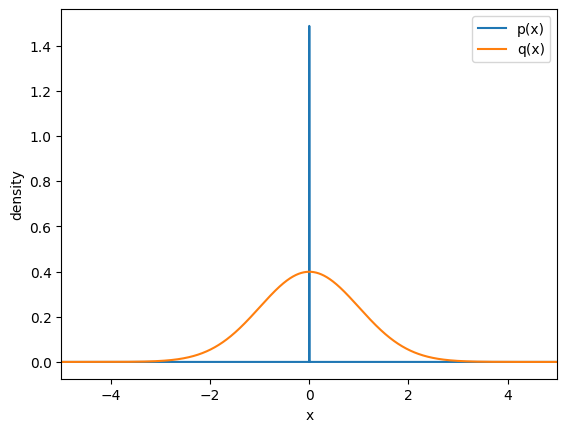

In [6]:
# plot known densities
x = np.linspace(-5, 5, 1_000_000)
p = gauss(x, 0, sigma_p)
q = gauss(x, 0, sigma_q)

plt.plot(x, p, label='p(x)')
plt.plot(x, q, label='q(x)')
plt.xlim(-5, 5)
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.show()


In [12]:
# --------------------------------------------------
# True log-ratio:
# log p(x)/q(x) = w_true * x^2 + b_true
# --------------------------------------------------
w_true = -1/(2*sigma_p**2) + 1/(2*sigma_q**2)
b_true = np.log(sigma_q / sigma_p)

In [8]:
# --------------------------------------------------
# Single-ratio model:
# log r_theta(x) = -exp(theta) * x^2 + b_true
# (same quadratic form, 1 parameter on log scale)
# --------------------------------------------------
def log_r(x, theta):
    return -np.exp(theta) * x**2 + b_true

# Logistic loss from the paper:
# L = -E_p log(r/(1+r)) - E_q log(1/(1+r))
# Using log_r for numerical stability
def loss(theta):
    lp = log_r(xp, theta)
    lq = log_r(xq, theta)
    return np.mean(np.logaddexp(0, -lp)) + np.mean(np.logaddexp(0, lq))

In [9]:
# --------------------------------------------------
# Fit theta by grid search (easy and stable in 1D)
# --------------------------------------------------
theta_grid = np.linspace(0, 35, 3000)
losses = np.array([loss(t) for t in theta_grid])

theta_hat = theta_grid[np.argmin(losses)]
w_hat = -np.exp(theta_hat)

theta_true = np.log(-w_true)

print("true theta =", theta_true)
print("est  theta =", theta_hat)
print("true w     =", w_true)
print("est  w     =", w_hat)
print("b_true     =", b_true)

true theta = 26.9378739353676
est  theta = 22.594198066022006
true w     = -499999999999.5
est  w     = -6494347798.047894
b_true     = 13.815510557964274


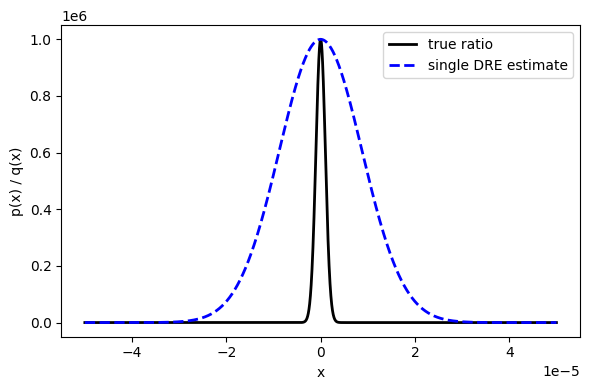

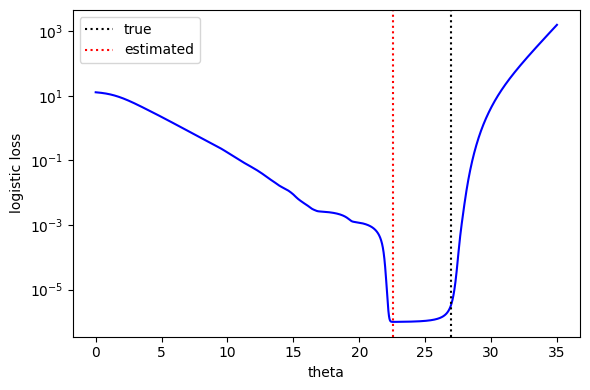

In [11]:
# --------------------------------------------------
# Plot true vs estimated ratio
# --------------------------------------------------
x = np.linspace(-5e-5, 5e-5, 5000)  # zoom near 0 so the ratio shape is visible

log_ratio_true = w_true * x**2 + b_true
log_ratio_hat  = w_hat  * x**2 + b_true

ratio_true = np.exp(np.clip(log_ratio_true, -745, 700))
ratio_hat  = np.exp(np.clip(log_ratio_hat,  -745, 700))

plt.figure(figsize=(6,4))
plt.plot(x, ratio_true, label='true ratio', color='black', linewidth=2)
plt.plot(x, ratio_hat, label='single DRE estimate', color='blue', linestyle='--', linewidth=2)
plt.xlabel('x')
plt.ylabel('p(x) / q(x)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(theta_grid, losses, color='blue')
plt.axvline(theta_true, color='black', linestyle=':', label='true')
plt.axvline(theta_hat, color='red', linestyle=':', label='estimated')
plt.yscale('log')
plt.xlabel('theta')
plt.ylabel('logistic loss')
plt.legend()
plt.tight_layout()
plt.show()

### Logistic TRE

Bridge-wise fits:
bridge 0: sigma_k=1.000e-06, sigma_k+1=3.162e-05
  true theta = 26.936873
  est  theta = 26.930871
  true w     = -4.995000e+11
  est  w     = -4.965110e+11
  b_true     = 3.453878

bridge 1: sigma_k=3.162e-05, sigma_k+1=1.000e-03
  true theta = 20.029118
  est  theta = 20.027117
  true w     = -4.995000e+08
  est  w     = -4.985017e+08
  b_true     = 3.453878

bridge 2: sigma_k=1.000e-03, sigma_k+1=3.162e-02
  true theta = 13.121363
  est  theta = 13.115361
  true w     = -4.995000e+05
  est  w     = -4.965110e+05
  b_true     = 3.453878

bridge 3: sigma_k=3.162e-02, sigma_k+1=1.000e+00
  true theta = 6.213608
  est  theta = 6.207606
  true w     = -4.995000e+02
  est  w     = -4.965110e+02
  b_true     = 3.453878



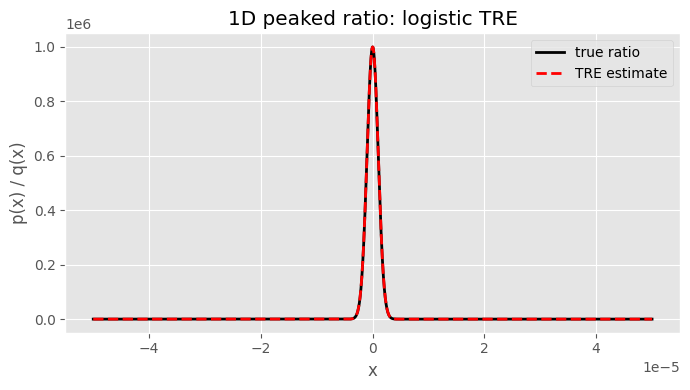

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Problem setup: peaked Gaussian p and broad Gaussian q
# ============================================================
sigma_p = 1e-6   # p(x) = N(0, sigma_p^2)
sigma_q = 1.0    # q(x) = N(0, sigma_q^2)
n = 10_000
rng = np.random.default_rng(0)

# Paired endpoint samples: x0 ~ p, xm ~ q
x0 = rng.normal(0.0, sigma_p, n)
xm = rng.normal(0.0, sigma_q, n)

# ============================================================
# 2) Choose waymarks
#    We'll use m bridges, so there are m+1 distributions:
#    p0 = p, p1, ..., pm = q
#
#    To make the intermediate problems sensible, we choose the
#    target std-devs geometrically between sigma_p and sigma_q:
#       sigma_0, sigma_1, ..., sigma_m
#
#    Then solve for alpha_k so that x_k has variance sigma_k^2.
# ============================================================
m = 4  # number of bridges; gives p0 -> p1 -> p2 -> p3 -> p4=q

sigmas = np.geomspace(sigma_p, sigma_q, m + 1)

# For interpolation
# x_k = sqrt(1 - alpha_k^2) * x0 + alpha_k * xm
# Since x0 ~ N(0, sigma_p^2), xm ~ N(0, sigma_q^2),
# the variance of x_k is:
#   Var(x_k) = (1-alpha_k^2)*sigma_p^2 + alpha_k^2*sigma_q^2
# Solve this for alpha_k so that Var(x_k) = sigmas[k]^2.
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[0] = 0.0
alphas[-1] = 1.0

# Build the waymark samples x_k for k=0,...,m
waymarks = []
for a in alphas:
    xk = np.sqrt(1 - a**2) * x0 + a * xm
    waymarks.append(xk)

# ============================================================
# 3) Ground-truth bridge coefficients
#
#    If p_k = N(0, sigma_k^2) and p_{k+1} = N(0, sigma_{k+1}^2),
#    then
#       log(p_k(x)/p_{k+1}(x)) = w_k^* x^2 + b_k^*
#
#    where
#       w_k^* = -1/(2 sigma_k^2) + 1/(2 sigma_{k+1}^2)
#       b_k^* = log(sigma_{k+1} / sigma_k)
#
#    We fix b_k to its ground-truth value, following the paper.
# ============================================================
w_true = []
b_true = []

for k in range(m):
    s0 = sigmas[k]
    s1 = sigmas[k + 1]
    wk = -1 / (2 * s0**2) + 1 / (2 * s1**2)
    bk = np.log(s1 / s0)
    w_true.append(wk)
    b_true.append(bk)

w_true = np.array(w_true)
b_true = np.array(b_true)

# ============================================================
# 4) Logistic loss for a single bridge
#
#    Model:
#       log r_k(x; theta_k) = -exp(theta_k) * x^2 + b_k
#
#    This is the same quadratic form as in the paper, with the
#    sign chosen correctly for this Gaussian example.
# ============================================================
def bridge_log_ratio(x, theta, b):
    return -np.exp(theta) * x**2 + b

def bridge_loss(theta, x_left, x_right, b):
    # Logistic DRE loss:
    #   -E_{x~p_k} log( r/(1+r) ) - E_{x~p_{k+1}} log( 1/(1+r) )
    #
    # Using log_r for numerical stability:
    #   log(1 + exp(-log_r)) = logaddexp(0, -log_r)
    #   log(1 + exp( log_r)) = logaddexp(0,  log_r)
    log_r_left = bridge_log_ratio(x_left, theta, b)
    log_r_right = bridge_log_ratio(x_right, theta, b)
    return np.mean(np.logaddexp(0, -log_r_left)) + np.mean(np.logaddexp(0, log_r_right))

# ============================================================
# 5) Fit each bridge separately by grid search
#
#    This keeps the 1D toy experiment very clean and stable.
# ============================================================
theta_hat = []
w_hat = []
bridge_losses = []
theta_grids = []

for k in range(m):
    x_left = waymarks[k]
    x_right = waymarks[k + 1]

    # True theta corresponding to w_k^* = -exp(theta_k^*)
    theta_true_k = np.log(-w_true[k])

    # Search in a window around the true value
    grid = np.linspace(theta_true_k - 6, theta_true_k + 6, 3000)
    losses = np.array([bridge_loss(t, x_left, x_right, b_true[k]) for t in grid])

    th = grid[np.argmin(losses)]
    wk = -np.exp(th)

    theta_grids.append(grid)
    bridge_losses.append(losses)
    theta_hat.append(th)
    w_hat.append(wk)

theta_hat = np.array(theta_hat)
w_hat = np.array(w_hat)

# ============================================================
# 6) Build the final TRE estimate:
#       log r_TRE(x) = sum_k log r_k(x)
# ============================================================
def log_ratio_true(x):
    # True single ratio log p(x)/q(x)
    return (-1/(2*sigma_p**2) + 1/(2*sigma_q**2)) * x**2 + np.log(sigma_q / sigma_p)

def log_ratio_tre(x):
    total = np.zeros_like(x)
    for k in range(m):
        total += w_hat[k] * x**2 + b_true[k]
    return total

# ============================================================
# 7) Print bridge parameters
# ============================================================
print("Bridge-wise fits:")
for k in range(m):
    print(f"bridge {k}: sigma_k={sigmas[k]:.3e}, sigma_k+1={sigmas[k+1]:.3e}")
    print(f"  true theta = {np.log(-w_true[k]):.6f}")
    print(f"  est  theta = {theta_hat[k]:.6f}")
    print(f"  true w     = {w_true[k]:.6e}")
    print(f"  est  w     = {w_hat[k]:.6e}")
    print(f"  b_true     = {b_true[k]:.6f}")
    print()

# ============================================================
# 8) Plot final TRE ratio vs true ratio
#    Zoom near 0, because the true ratio is extremely peaked.
# ============================================================
x_plot = np.linspace(-5e-5, 5e-5, 5000)

log_r_true = log_ratio_true(x_plot)
log_r_tre = log_ratio_tre(x_plot)

r_true = np.exp(np.clip(log_r_true, -745, 700))
r_tre = np.exp(np.clip(log_r_tre, -745, 700))

plt.figure(figsize=(7, 4))
plt.plot(x_plot, r_true, color='black', linewidth=2, label='true ratio')
plt.plot(x_plot, r_tre, color='red', linestyle='--', linewidth=2, label='TRE estimate')
plt.xlabel('x')
plt.ylabel('p(x) / q(x)')
plt.title('1D peaked ratio: logistic TRE')
plt.legend()
plt.tight_layout()
plt.show()

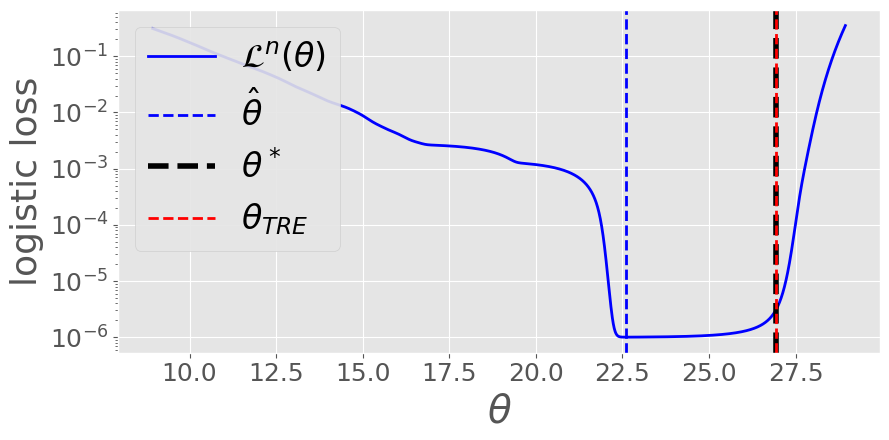

In [26]:
# ============================================================
# 9) Single-ratio logistic DRE loss curve + Figure 1a-style plot
# ============================================================

# True single-ratio parameters:
#   log r(x) = w_single_true * x^2 + b_single_true
w_single_true = -1/(2*sigma_p**2) + 1/(2*sigma_q**2)
b_single_true = np.log(sigma_q / sigma_p)

# Single-ratio model:
#   log r_theta(x) = -exp(theta) * x^2 + b_single_true
def single_log_ratio(x, theta):
    return -np.exp(theta) * x**2 + b_single_true

# Logistic loss for the single DRE case
def single_loss(theta):
    log_r_p = single_log_ratio(x0, theta)   # samples from p
    log_r_q = single_log_ratio(xm, theta)   # samples from q
    return np.mean(np.logaddexp(0, -log_r_p)) + np.mean(np.logaddexp(0, log_r_q))

# True theta for the single-ratio problem
theta_true = np.log(-w_single_true)

# Empirical TRE-equivalent theta:
# log r_TRE(x) = (sum_k w_hat[k]) x^2 + sum_k b_k
# so the total quadratic coefficient is sum_k w_hat[k]
theta_tre = np.log(-np.sum(w_hat))

# Build a theta grid for the single-ratio loss curve
theta_grid = np.linspace(theta_true - 18, theta_true + 2, 3000)
losses = np.array([single_loss(t) for t in theta_grid])

# Single DRE empirical minimizer
theta_hat = theta_grid[np.argmin(losses)]

# ============================================================
# 10) Plot like the paper figure
# ============================================================
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(theta_grid, losses, color='blue', lw=2, label=r'$\mathcal{L}^n(\theta)$')
ax.axvline(theta_hat,  color='blue',  ls='--', lw=2, label=r'$\hat{\theta}$')
ax.axvline(theta_true, color='black', ls='--', lw=4, label=r'$\theta^*$')
ax.axvline(theta_tre,  color='red',   ls='--', lw=2, label=r'$\theta_{TRE}$')

ax.set_xlabel(r'$\theta$', fontsize=28)
ax.set_ylabel('logistic loss', fontsize=26)
ax.tick_params(labelsize=18)
ax.legend(loc='upper left', fontsize=24, framealpha=0.9)

plt.yscale('log')
plt.tight_layout()
plt.show()


Bridge-wise fits (Expected Bregman divergence, squared loss):
bridge 0: sigma_t=1.000e-06, sigma_t+1=3.162e-05
  true theta = 26.936873
  est  theta = 26.938874
  true w     = -4.995000e+11
  est  w     = -5.005003e+11
  b_true     = 3.453878

bridge 1: sigma_t=3.162e-05, sigma_t+1=1.000e-03
  true theta = 20.029118
  est  theta = 20.031119
  true w     = -4.995000e+08
  est  w     = -5.005003e+08
  b_true     = 3.453878

bridge 2: sigma_t=1.000e-03, sigma_t+1=3.162e-02
  true theta = 13.121363
  est  theta = 13.123364
  true w     = -4.995000e+05
  est  w     = -5.005003e+05
  b_true     = 3.453878

bridge 3: sigma_t=3.162e-02, sigma_t+1=1.000e+00
  true theta = 6.213608
  est  theta = 6.215608
  true w     = -4.995000e+02
  est  w     = -5.005003e+02
  b_true     = 3.453878



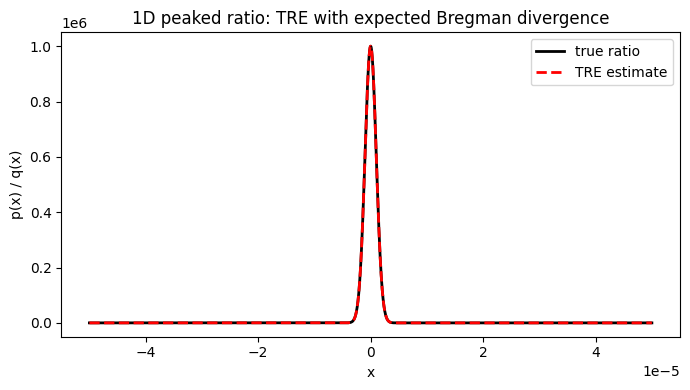

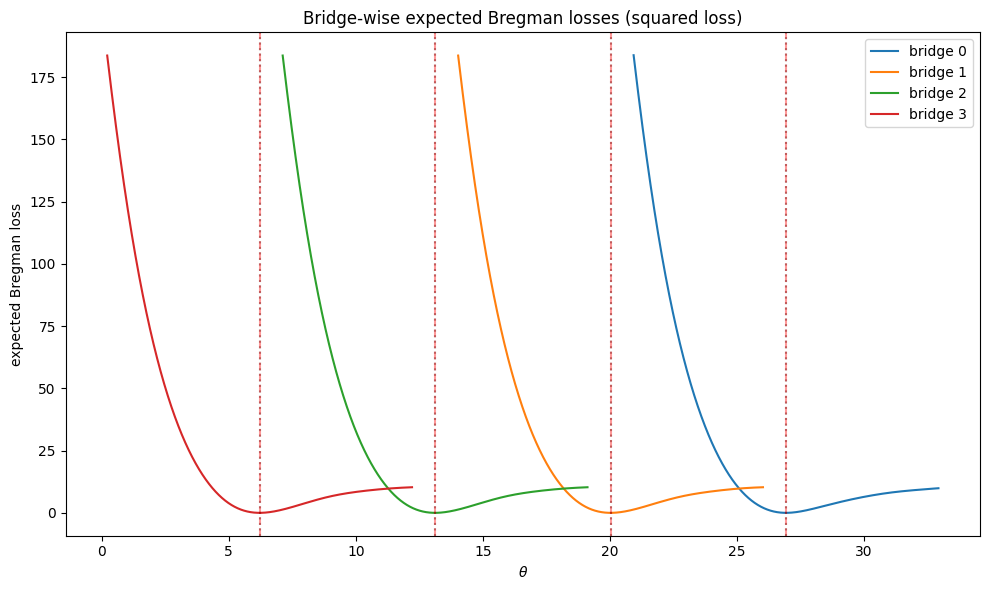

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Problem setup: peaked Gaussian p and broad Gaussian q
# ============================================================
sigma_p = 1e-6   # p(x) = N(0, sigma_p^2)
sigma_q = 1.0    # q(x) = N(0, sigma_q^2)
n = 10_000
rng = np.random.default_rng(0)

# Paired endpoint samples: x0 ~ p, xm ~ q
x0 = rng.normal(0.0, sigma_p, n)
xm = rng.normal(0.0, sigma_q, n)

# ============================================================
# 2) Choose waymarks
#    p0 = p, p1, ..., pm = q
# ============================================================
m = 4  # number of bridges

sigmas = np.geomspace(sigma_p, sigma_q, m + 1)

# x_k = sqrt(1 - alpha_k^2) * x0 + alpha_k * xm
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[0] = 0.0
alphas[-1] = 1.0

waymarks = []
for a in alphas:
    xk = np.sqrt(1 - a**2) * x0 + a * xm
    waymarks.append(xk)

# ============================================================
# 3) Ground-truth bridge coefficients
#
#    For p_k = N(0, sigma_k^2), p_{k+1} = N(0, sigma_{k+1}^2):
#       log(p_k(x)/p_{k+1}(x)) = w_k^* x^2 + b_k^*
#
#    Since the DRE operator is
#       A_t[p_{t+1}](x) = (∫ p_{t+1}) p_t(x),
#    and the Gaussian densities are normalized, ∫ p_{t+1} = 1,
#    so the target ratio is simply:
#       r_t(x) = p_t(x) / p_{t+1}(x)
# ============================================================
w_true = []
b_true = []

for k in range(m):
    s0 = sigmas[k]
    s1 = sigmas[k + 1]
    wk = -1 / (2 * s0**2) + 1 / (2 * s1**2)
    bk = np.log(s1 / s0)
    w_true.append(wk)
    b_true.append(bk)

w_true = np.array(w_true)
b_true = np.array(b_true)

# ============================================================
# 4) True bridge ratio and model theta_q
#
#    We parametrize theta_q(x,t) using the same quadratic form:
#       log theta_q(x,t) = -exp(theta_t) * x^2 + b_t
#
#    So theta_q(x,t) itself is
#       theta_q(x,t) = exp( -exp(theta_t) * x^2 + b_t )
#
#    The true target bridge ratio is
#       r_t(x) = exp( w_true[t] * x^2 + b_true[t] )
# ============================================================
def true_bridge_ratio(x, t):
    return np.exp(np.clip(w_true[t] * x**2 + b_true[t], -745, 700))

def theta_q(x, theta, b):
    log_q = -np.exp(theta) * x**2 + b
    return np.exp(np.clip(log_q, -745, 700))

# ============================================================
# 5) Bregman divergence for squared loss
#
#    Choose F(u) = 1/2 * u^2
#    Then:
#       B_F(u, v) = F(u) - F(v) - F'(v)(u - v)
#                  = 1/2 * (u - v)^2
#
#    Expected objective at bridge t:
#       D_F(r_t, theta_q(. , t))
#       = E_{x ~ p_{t+1}} [ 1/2 * (r_t(x) - theta_q(x,t))^2 ]
# ============================================================
def F(u):
    return 0.5 * u**2

def dF(u):
    return u

def B_F(u, v):
    return F(u) - F(v) - dF(v) * (u - v)

def expected_bregman_loss(theta, x_next, t):
    # x_next are samples from p_{t+1}
    r_t = true_bridge_ratio(x_next, t)
    q_t = theta_q(x_next, theta, b_true[t])
    return np.mean(B_F(r_t, q_t))

# ============================================================
# 6) Fit each bridge by minimizing the expected Bregman loss
#    using Monte Carlo samples from p_{t+1}
# ============================================================
theta_hat = []
w_hat = []
bridge_losses = []
theta_grids = []

for t in range(m):
    x_next = waymarks[t + 1]   # expectation under p_{t+1}

    # True theta satisfies w_true[t] = -exp(theta_true_t)
    theta_true_t = np.log(-w_true[t])

    # Search in a window around the true value
    grid = np.linspace(theta_true_t - 6, theta_true_t + 6, 3000)
    losses = np.array([expected_bregman_loss(th, x_next, t) for th in grid])

    th_hat = grid[np.argmin(losses)]
    wk_hat = -np.exp(th_hat)

    theta_grids.append(grid)
    bridge_losses.append(losses)
    theta_hat.append(th_hat)
    w_hat.append(wk_hat)

theta_hat = np.array(theta_hat)
w_hat = np.array(w_hat)

# ============================================================
# 7) Build the final TRE estimate:
#       r_TRE(x) = Π_t theta_q(x,t)
#    so in log-space:
#       log r_TRE(x) = Σ_t [ w_hat[t] x^2 + b_true[t] ]
# ============================================================
def log_ratio_true(x):
    return (-1/(2*sigma_p**2) + 1/(2*sigma_q**2)) * x**2 + np.log(sigma_q / sigma_p)

def log_ratio_tre(x):
    total = np.zeros_like(x)
    for t in range(m):
        total += w_hat[t] * x**2 + b_true[t]
    return total

# ============================================================
# 8) Print bridge parameters
# ============================================================
print("Bridge-wise fits (Expected Bregman divergence, squared loss):")
for t in range(m):
    print(f"bridge {t}: sigma_t={sigmas[t]:.3e}, sigma_t+1={sigmas[t+1]:.3e}")
    print(f"  true theta = {np.log(-w_true[t]):.6f}")
    print(f"  est  theta = {theta_hat[t]:.6f}")
    print(f"  true w     = {w_true[t]:.6e}")
    print(f"  est  w     = {w_hat[t]:.6e}")
    print(f"  b_true     = {b_true[t]:.6f}")
    print()

# ============================================================
# 9) Plot final TRE ratio vs true ratio
# ============================================================
x_plot = np.linspace(-5e-5, 5e-5, 5000)

log_r_true = log_ratio_true(x_plot)
log_r_tre = log_ratio_tre(x_plot)

r_true = np.exp(np.clip(log_r_true, -745, 700))
r_tre = np.exp(np.clip(log_r_tre, -745, 700))

plt.figure(figsize=(7, 4))
plt.plot(x_plot, r_true, color='black', linewidth=2, label='true ratio')
plt.plot(x_plot, r_tre, color='red', linestyle='--', linewidth=2, label='TRE estimate')
plt.xlabel('x')
plt.ylabel('p(x) / q(x)')
plt.title('1D peaked ratio: TRE with expected Bregman divergence')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

# ============================================================
# Configuration
# ============================================================
sigma_p = 1e-6
sigma_q = 1.0
n = 10_000
m = 4
n_tries = 5

# ============================================================
# Ground-truth single-ratio parameters
# log(p(x)/q(x)) = w_single_true * x^2 + b_single_true
# ============================================================
w_single_true = -1 / (2 * sigma_p**2) + 1 / (2 * sigma_q**2)
b_single_true = np.log(sigma_q / sigma_p)
theta_true = np.log(-w_single_true)

# ============================================================
# Waymark stds and ground-truth bridge parameters
# log(p_t / p_{t+1}) = w_true[t] * x^2 + b_true[t]
# ============================================================
sigmas = np.geomspace(sigma_p, sigma_q, m + 1)
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[0], alphas[-1] = 0.0, 1.0

w_true = np.array([
    -1 / (2 * sigmas[t]**2) + 1 / (2 * sigmas[t + 1]**2)
    for t in range(m)
])
b_true = np.array([
    np.log(sigmas[t + 1] / sigmas[t])
    for t in range(m)
])

# ============================================================
# Helpers
# ============================================================
def exp_clip(z):
    return np.exp(np.clip(z, -745, 700))

def log_model(x, theta, b):
    # log r_theta(x) = -exp(theta) * x^2 + b
    return -np.exp(theta) * x**2 + b

def model_ratio(x, theta, b):
    return exp_clip(log_model(x, theta, b))

def true_ratio(x, w, b):
    return exp_clip(w * x**2 + b)

def fit_on_grid(loss_fn, theta_center, width, n_grid=3000):
    grid = np.linspace(theta_center - width, theta_center + width, n_grid)
    losses = np.array([loss_fn(th) for th in grid])
    theta_hat = grid[np.argmin(losses)]
    w_hat = -np.exp(theta_hat)
    return theta_hat, w_hat

def theta_metrics(theta_est, theta_ref):
    abs_err = abs(theta_est - theta_ref)
    rel_err = abs_err / abs(theta_ref)
    score = 100.0 * max(0.0, 1.0 - rel_err)   # accuracy-like score
    return abs_err, rel_err, score

# ============================================================
# One run
# ============================================================
def run_once(seed):
    rng = np.random.default_rng(seed)

    # Samples from p and q
    xp = rng.normal(0.0, sigma_p, n)
    xq = rng.normal(0.0, sigma_q, n)

    # Waymarks
    waymarks = [np.sqrt(1 - a**2) * xp + a * xq for a in alphas]

    # --------------------------------------------------------
    # 1) Single-ratio logistic baseline
    # --------------------------------------------------------
    def single_logistic_loss(theta):
        lp = log_model(xp, theta, b_single_true)
        lq = log_model(xq, theta, b_single_true)
        return np.mean(np.logaddexp(0, -lp)) + np.mean(np.logaddexp(0, lq))

    theta_single, _ = fit_on_grid(
        single_logistic_loss,
        theta_center=theta_true,
        width=18.0
    )

    # --------------------------------------------------------
    # 2) Logistic TRE
    # --------------------------------------------------------
    def logistic_bridge_loss(theta, x_left, x_right, b):
        log_r_left = log_model(x_left, theta, b)
        log_r_right = log_model(x_right, theta, b)
        return np.mean(np.logaddexp(0, -log_r_left)) + np.mean(np.logaddexp(0, log_r_right))

    w_logistic_bridges = []
    theta_logistic_bridges = []

    for t in range(m):
        theta_t, w_t = fit_on_grid(
            lambda th, t=t: logistic_bridge_loss(th, waymarks[t], waymarks[t + 1], b_true[t]),
            theta_center=np.log(-w_true[t]),
            width=6.0
        )
        theta_logistic_bridges.append(theta_t)
        w_logistic_bridges.append(w_t)

    theta_logistic_bridges = np.array(theta_logistic_bridges)
    w_logistic_bridges = np.array(w_logistic_bridges)
    theta_logistic_tre = np.log(-np.sum(w_logistic_bridges))

    # --------------------------------------------------------
    # 3) BLOD TRE (Bregman / squared loss)
    # --------------------------------------------------------
    def bregman_bridge_loss(theta, t):
        x_next = waymarks[t + 1]   # expectation under p_{t+1}
        r_t = true_ratio(x_next, w_true[t], b_true[t])
        q_t = model_ratio(x_next, theta, b_true[t])
        return np.mean(0.5 * (r_t - q_t) ** 2)

    w_bregman_bridges = []
    theta_bregman_bridges = []

    for t in range(m):
        theta_t, w_t = fit_on_grid(
            lambda th, t=t: bregman_bridge_loss(th, t),
            theta_center=np.log(-w_true[t]),
            width=6.0
        )
        theta_bregman_bridges.append(theta_t)
        w_bregman_bridges.append(w_t)

    theta_bregman_bridges = np.array(theta_bregman_bridges)
    w_bregman_bridges = np.array(w_bregman_bridges)
    theta_bregman_tre = np.log(-np.sum(w_bregman_bridges))

    return {
        "Single (logistic)": theta_single,
        "Logistic TRE": theta_logistic_tre,
        "BLOD TRE": theta_bregman_tre,
        "Logistic TRE bridges": theta_logistic_bridges,
        "BLOD TRE bridges": theta_bregman_bridges,
    }

# ============================================================
# Run over multiple tries
# ============================================================
all_results = []
for seed in range(n_tries):
    all_results.append(run_once(seed))

# ============================================================
# Aggregate results
# ============================================================
methods = ["Single (logistic)", "Logistic TRE", "BLOD TRE"]

print(f"theta_true = {theta_true:.6f}\n")
print(f"Averaged over {n_tries} tries:\n")

for method in methods:
    thetas = np.array([res[method] for res in all_results])

    abs_errs = []
    rel_errs = []
    scores = []
    for theta_est in thetas:
        abs_err, rel_err, score = theta_metrics(theta_est, theta_true)
        abs_errs.append(abs_err)
        rel_errs.append(rel_err)
        scores.append(score)

    abs_errs = np.array(abs_errs)
    rel_errs = np.array(rel_errs)
    scores = np.array(scores)

    print(f"{method:18s}")
    print(f"  theta      = {thetas.mean():.6f} ± {thetas.std(ddof=1):.6f}")
    print(f"  |error|    = {abs_errs.mean():.6f} ± {abs_errs.std(ddof=1):.6f}")
    print(f"  rel_error  = {100*rel_errs.mean():.4f}% ± {100*rel_errs.std(ddof=1):.4f}%")
    print(f"  theta_score= {scores.mean():.2f}% ± {scores.std(ddof=1):.2f}%")
    print()

# Optional: average bridge-wise thetas too
logistic_bridge_thetas = np.array([res["Logistic TRE bridges"] for res in all_results])
bregman_bridge_thetas = np.array([res["BLOD TRE bridges"] for res in all_results])

print("Average bridge-wise thetas:")
print("  Logistic TRE:", np.round(logistic_bridge_thetas.mean(axis=0), 6))
print("  BLOD TRE:    ", np.round(bregman_bridge_thetas.mean(axis=0), 6))

theta_true = 26.937874

Averaged over 5 tries:

Single (logistic) 
  theta      = 22.632039 ± 1.993358
  |error|    = 4.305835 ± 1.993358
  rel_error  = 15.9843% ± 7.3998%
  theta_score= 84.02% ± 7.40%

Logistic TRE      
  theta      = 26.932686 ± 0.015072
  |error|    = 0.012398 ± 0.008286
  rel_error  = 0.0460% ± 0.0308%
  theta_score= 99.95% ± 0.03%

BLOD TRE          
  theta      = 26.939875 ± 0.000000
  |error|    = 0.002001 ± 0.000000
  rel_error  = 0.0074% ± 0.0000%
  theta_score= 99.99% ± 0.00%

Average bridge-wise thetas:
  Logistic TRE: [26.931672 20.037521 13.129766  6.22201 ]
  BLOD TRE:     [26.938874 20.031119 13.123364  6.215608]


In [6]:
import numpy as np

# -----------------------------
# settings
# -----------------------------
sigma_p, sigma_q = 1e-6, 1.0
n, m, n_tries = 10_000, 4, 5

# -----------------------------
# true single-ratio parameters
# log(p/q) = w* x^2 + b*
# -----------------------------
w_star = 1/2 * ((1/sigma_q**2) - (1/sigma_p**2))
b_star = np.log(sigma_q / sigma_p)
theta_star = np.log(-w_star)

# -----------------------------
# waymark setup
# -----------------------------
sigmas = np.geomspace(sigma_p, sigma_q, m + 1)
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[[0, -1]] = 0.0, 1.0

w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])

# -----------------------------
# helpers
# -----------------------------

def log_ratio_model(x, theta, b):
    """
    Log density-ratio *model* for a Gaussian-to-Gaussian ratio.

    THEORY
    ------
    For two zero-mean Gaussians:
        p(x) = N(0, σ_p^2)
        q(x) = N(0, σ_q^2)

    the true log density ratio has the form:
        log(p(x)/q(x)) = w x^2 + b

    where:
        w = -1/(2σ_p^2) + 1/(2σ_q^2)    (note: w < 0 if σ_p < σ_q)
        b = log(σ_q / σ_p)

    PARAMETERIZATION
    ----------------
    We *reparameterize* the quadratic coefficient as:
        w = -exp(theta)

    This guarantees:
        - w < 0 automatically
        - theta is unconstrained (theta ∈ ℝ)
        - numerical stability during optimization

    So the modeled log-ratio is:
        log r(x; θ, b) = -exp(θ) * x^2 + b

    INPUTS
    ------
    x     : scalar or array of samples
    theta : unconstrained curvature parameter
    b     : bias (normalization term)

    OUTPUT
    ------
    log r(x) evaluated at x
    """
    return -np.exp(theta) * x**2 + b


def ratio_from_log(log_r):
    """
    Convert log-ratio values into ratio values safely.

    NUMERICAL ISSUE
    ---------------
    r(x) = exp(log r(x)) can overflow / underflow:
      - exp(> ~700)  → inf
      - exp(< ~-745) → 0 (underflow to 0)

    SOLUTION
    --------
    We clip log-ratios to a safe floating-point range before exponentiating.

    This does NOT change the mathematical model —
    it only prevents numerical crashes.

    INPUT
    -----
    log_r : array or scalar of log-ratio values

    OUTPUT
    ------
    r(x) = exp(log_r), numerically stabilized
    """
    return np.exp(np.clip(log_r, -745, 700))


def ratio_model(x, theta, b):
    """
    Full **modeled density ratio** r(x; θ, b).

    This is just the composition:
        r(x) = exp(log r(x))

    where log r(x) is given by the quadratic model:
        log r(x) = -exp(theta) * x^2 + b

    INPUTS
    ------
    x     : samples
    theta : curvature parameter (unconstrained)
    b     : bias

    OUTPUT
    ------
    Modeled density ratio r(x)
    """
    return ratio_from_log(log_ratio_model(x, theta, b))


def ratio_true(x, w, b):
    """
    Ground-truth density ratio for Gaussian pairs.

    THEORY
    ------
    If we know the *true* parameters:
        w = -1/(2σ_p^2) + 1/(2σ_q^2)
        b = log(σ_q / σ_p)

    then the exact ratio is:
        r*(x) = exp(w x^2 + b)

    This function is used:
        - for diagnostics
        - for sanity checks
        - to compare learned vs true models

    INPUTS
    ------
    x : samples
    w : true quadratic coefficient (negative)
    b : true bias

    OUTPUT
    ------
    True density ratio r*(x)
    """
    return ratio_from_log(w * x**2 + b)


def fit_theta(loss_fn, center, width, n_grid=3000):
    """
    Brute-force 1D optimization over theta.

    PURPOSE
    -------
    Since the model:
        w = -exp(theta)

    is *nonlinear*, we optimize in theta-space.
    This helper does a simple grid search.

    PROCEDURE
    ---------
    1. Build a grid:
           theta ∈ [center - width, center + width]
    2. Evaluate the loss at each grid point
    3. Select the minimizer

    This is:
        - slow but robust
        - useful for experiments & debugging
        - avoids gradient pathologies

    RETURNED VALUES
    ---------------
    theta_hat : best theta found
    w_hat     : corresponding quadratic coefficient
                (computed via w = -exp(theta))

    NOTE
    ----
    This mirrors the theory exactly:
        theta* = log(-w*)
    """
    grid = np.linspace(center - width, center + width, n_grid)

    # Evaluate loss(theta) for each candidate theta
    theta = grid[np.argmin([loss_fn(t) for t in grid])]

    # Return both theta and the implied quadratic coefficient
    return theta, -np.exp(theta)

def metrics(theta, theta_ref):
    err = abs(theta - theta_ref)
    rel = err / abs(theta_ref)
    score = 100 * max(0.0, 1 - rel)
    return err, rel, score

def summarize(name, values, theta_ref):
    values = np.array(values)
    errs, rels, scores = np.array([metrics(v, theta_ref) for v in values]).T
    print(f"{name:18s}")
    print(f"  theta       = {values.mean():.6f} ± {values.std(ddof=1):.6f}")
    print(f"  |error|     = {errs.mean():.6f} ± {errs.std(ddof=1):.6f}")
    print(f"  rel_error   = {100*rels.mean():.4f}% ± {100*rels.std(ddof=1):.4f}%")
    print(f"  theta_score = {scores.mean():.2f}% ± {scores.std(ddof=1):.2f}%")
    print()

# -----------------------------
# one experiment
# -----------------------------
def run(seed):
    """
    Run a single experimental trial comparing:

      1) A single-shot density ratio fit (no waymarks)
      2) Logistic TRE with waymarks
      3) BLOD / Bregman TRE with waymarks

    All methods ultimately estimate the *same global quadratic curvature*
    corresponding to:
        log(p(x)/q(x)) = w* x^2 + b*

    The difference is HOW that curvature is estimated.
    """

    # Random number generator for reproducibility
    rng = np.random.default_rng(seed)

    # ---------------------------------------------------------
    # Sample from endpoint distributions
    # ---------------------------------------------------------
    # p(x) = N(0, sigma_p^2)
    # q(x) = N(0, sigma_q^2)
    xp = rng.normal(0.0, sigma_p, n)
    xq = rng.normal(0.0, sigma_q, n)

    # ---------------------------------------------------------
    # Construct waymark samples (paper Eq. 5)
    # ---------------------------------------------------------
    # Paper definition:
    #   x_k = sqrt(1 - alpha_k^2) * x_0 + alpha_k * x_m
    #
    # Here:
    #   x_0 ↔ xp samples
    #   x_m ↔ xq samples
    #
    # For Gaussian endpoints, this induces:
    #   x_k ~ N(0, sigma_k^2)
    # with sigma_k^2 = (1 - alpha_k^2) sigma_p^2 + alpha_k^2 sigma_q^2
    #
    # These are *sample-space* realizations of the paper's waymarks.
    waymarks = [np.sqrt(1 - a**2) * xp + a * xq for a in alphas]

    # =========================================================
    # 1) SINGLE-SHOT LOGISTIC RATIO ESTIMATION
    # =========================================================
    # Fit a *single* quadratic log-ratio model directly between p and q:
    #
    #   log r(x) = -exp(theta) * x^2 + b*
    #
    # using logistic loss (noise-contrastive-style objective).

    def single_loss(theta):
        """
        Logistic loss for direct p vs q classification.

        For samples x ~ p:
            contribution = log(1 + exp(-log r(x)))
        For samples x ~ q:
            contribution = log(1 + exp(+log r(x)))

        This corresponds to fitting:
            r(x) ≈ p(x) / q(x)
        via logistic regression on log densities.
        """
        lp = log_ratio_model(xp, theta, b_star)
        lq = log_ratio_model(xq, theta, b_star)

        return (
            np.mean(np.logaddexp(0, -lp)) +
            np.mean(np.logaddexp(0,  lq))
        )

    # Optimize theta around the true value theta*
    theta_single, _ = fit_theta(single_loss, theta_star, width=18.0)

    # =========================================================
    # 2) WAYMARKED TRE: GENERIC FITTER
    # =========================================================
    # Helper that fits a *separate* theta_t for each bridge:
    #
    #   log (p_{t+1}(x) / p_t(x))
    #
    # using a user-specified loss.

    def fit_bridges(loss_builder):
        """
        Fit one theta per bridge t = 0,...,m-1.

        Each theta_t corresponds to:
            w_t = -exp(theta_t)

        These w_t's will later be summed to recover the
        global curvature of log(p/q).
        """
        thetas, ws = [], []

        for t in range(m):
            # Each bridge has a known analytic optimum:
            #   theta_t* = log(-w_bridge_star[t])
            theta_t, w_t = fit_theta(
                lambda th, t=t: loss_builder(th, t),
                center=np.log(-w_bridge_star[t]),
                width=6.0
            )
            thetas.append(theta_t)
            ws.append(w_t)

        return np.array(thetas), np.array(ws)

    # =========================================================
    # 2a) LOGISTIC TRE (Waymark-by-waymark)
    # =========================================================
    # Apply the same logistic ratio loss as before,
    # but *locally* between consecutive waymarks:
    #
    #   p_t(x)  vs  p_{t+1}(x)

    def logistic_bridge_loss(theta, t):
        """
        Logistic loss for bridge t.

        Fits:
            log (p_{t+1}(x) / p_t(x))
            ≈ -exp(theta) * x^2 + b_t

        using samples drawn from:
            x ~ p_t   (left)
            x ~ p_{t+1} (right)
        """
        left  = log_ratio_model(waymarks[t],     theta, b_bridge_star[t])
        right = log_ratio_model(waymarks[t + 1], theta, b_bridge_star[t])

        return (
            np.mean(np.logaddexp(0, -left)) +
            np.mean(np.logaddexp(0,  right))
        )

    theta_log_bridges, w_log_bridges = fit_bridges(logistic_bridge_loss)

    # Telescoping sum of curvatures:
    #   sum_t w_t ≈ w*
    #
    # Convert to global theta via:
    #   w* = -exp(theta*)
    theta_log_tre = np.log(-w_log_bridges.sum())

    # =========================================================
    # 2b) BLOD / BREGMAN (SQUARED-ERROR) TRE
    # =========================================================
    # Instead of logistic classification, use a regression loss:
    #
    #   0.5 * E[(r_true(x) - r_model(x))^2]
    #
    # This is the Bregman divergence induced by φ(r) = 0.5 r^2.

    def blod_bridge_loss(theta, t):
        """
        BLOD loss for bridge t.

        Here we *know* the true ratio between p_t and p_{t+1}:
            r*_t(x) = exp(w_t* x^2 + b_t*)

        We regress the model ratio directly onto this target.
        """
        x_next = waymarks[t + 1]

        r_true  = ratio_true(x_next, w_bridge_star[t], b_bridge_star[t])
        r_model = ratio_model(x_next, theta, b_bridge_star[t])

        return np.mean(0.5 * (r_true - r_model) ** 2)

    theta_blod_bridges, w_blod_bridges = fit_bridges(blod_bridge_loss)

    # Again, telescope curvatures to recover global curvature
    theta_blod_tre = np.log(-w_blod_bridges.sum())

    # =========================================================
    # RETURN RESULTS
    # =========================================================
    return {
        # Direct single-shot estimate
        "Single (logistic)": theta_single,

        # Waymarked, sum of logistic bridges
        "Logistic TRE": theta_log_tre,

        # Waymarked, sum of BLOD bridges
        "BLOD TRE": theta_blod_tre,

        # Per-bridge parameters (for diagnostics)
        "Logistic TRE bridges": theta_log_bridges,
        "BLOD TRE bridges": theta_blod_bridges,
    }

# -----------------------------
# run 5 trials
# -----------------------------
results = [run(seed) for seed in range(n_tries)]

print(f"theta_true = {theta_star:.6f}\n")
print(f"Averaged over {n_tries} tries:\n")

for name in ["Single (logistic)", "Logistic TRE", "BLOD TRE"]:
    summarize(name, [r[name] for r in results], theta_star)

log_bridges = np.array([r["Logistic TRE bridges"] for r in results])
blod_bridges = np.array([r["BLOD TRE bridges"] for r in results])

print("Average bridge-wise thetas:")
print("  Logistic TRE:", np.round(log_bridges.mean(axis=0), 6))
print("  BLOD TRE:    ", np.round(blod_bridges.mean(axis=0), 6))

theta_true = 26.937874

Averaged over 5 tries:

Single (logistic) 
  theta       = 22.632039 ± 1.993358
  |error|     = 4.305835 ± 1.993358
  rel_error   = 15.9843% ± 7.3998%
  theta_score = 84.02% ± 7.40%

Logistic TRE      
  theta       = 26.932686 ± 0.015072
  |error|     = 0.012398 ± 0.008286
  rel_error   = 0.0460% ± 0.0308%
  theta_score = 99.95% ± 0.03%

BLOD TRE          
  theta       = 26.939875 ± 0.000000
  |error|     = 0.002001 ± 0.000000
  rel_error   = 0.0074% ± 0.0000%
  theta_score = 99.99% ± 0.00%

Average bridge-wise thetas:
  Logistic TRE: [26.931672 20.037521 13.129766  6.22201 ]
  BLOD TRE:     [26.938874 20.031119 13.123364  6.215608]


In [9]:
import numpy as np
from scipy.stats import wilcoxon

def abs_theta_errors(results, method, theta_true):
    return np.array([abs(r[method] - theta_true) for r in results])

def compare_methods(results, a, b, theta_true):
    ea = abs_theta_errors(results, a, theta_true)
    eb = abs_theta_errors(results, b, theta_true)
    diff = ea - eb   # positive means b is better (smaller error)

    stat, p = wilcoxon(diff, alternative="greater")

    print(f"{a} vs {b}")
    print(f"  mean error {a}: {ea.mean():.6f}")
    print(f"  mean error {b}: {eb.mean():.6f}")
    print(f"  mean paired improvement ({a} - {b}): {diff.mean():.6f}")
    print(f"  p-value: {p:.6f}")
    print()

compare_methods(results, "Single (logistic)", "Logistic TRE", theta_star)
compare_methods(results, "Single (logistic)", "BLOD TRE", theta_star)
compare_methods(results, "Logistic TRE", "BLOD TRE", theta_star)


Single (logistic) vs Logistic TRE
  mean error Single (logistic): 4.305835
  mean error Logistic TRE: 0.012398
  mean paired improvement (Single (logistic) - Logistic TRE): 4.293437
  p-value: 0.031250

Single (logistic) vs BLOD TRE
  mean error Single (logistic): 4.305835
  mean error BLOD TRE: 0.002001
  mean paired improvement (Single (logistic) - BLOD TRE): 4.303835
  p-value: 0.031250

Logistic TRE vs BLOD TRE
  mean error Logistic TRE: 0.012398
  mean error BLOD TRE: 0.002001
  mean paired improvement (Logistic TRE - BLOD TRE): 0.010398
  p-value: 0.031250



### Single DRE

## Single-ratio logistic DRE: paper $\to$ code

### 1. Paper’s logistic density-ratio loss

The TRE paper defines the single-ratio logistic loss as

$$
\mathcal L(\theta)
=
- \mathbb E_{x_1\sim p}
\log\!\left(\frac{r(x_1;\theta)}{1+r(x_1;\theta)}\right)
-
\mathbb E_{x_2\sim q}
\log\!\left(\frac{1}{1+r(x_2;\theta)}\right).
$$

Here:
- $x_1 \sim p$: sample from the numerator distribution $p$,
- $x_2 \sim q$: sample from the denominator distribution $q$,
- $r(x;\theta)$: model for the density ratio $p(x)/q(x)$,
- $\theta$: model parameter.

---

### 2. Rewrite the loss in log-ratio form

Define the modeled log-ratio

$$
\ell_\theta(x) := \log r(x;\theta),
\qquad\text{so that}\qquad
r(x;\theta)=e^{\ell_\theta(x)}.
$$

Then the first term becomes

$$
-\log\!\left(\frac{r}{1+r}\right)
=
-\bigl(\log r - \log(1+r)\bigr)
=
\log(1+r)-\log r
=
\log(1+e^{-\ell}),
$$

and the second term becomes

$$
-\log\!\left(\frac{1}{1+r}\right)
=
\log(1+r)
=
\log(1+e^\ell).
$$

So the loss can be written as

$$
\boxed{
\mathcal L(\theta)
=
\mathbb E_{x\sim p}\!\left[\log(1+e^{-\ell_\theta(x)})\right]
+
\mathbb E_{x\sim q}\!\left[\log(1+e^{\ell_\theta(x)})\right].
}
$$

This is exactly what the code computes, since

$$
\texttt{np.logaddexp(0, z)} = \log(1+e^z).
$$

---

### 3. Why the minimizer is the true log-density ratio

For a fixed $x$, write

$$
p = p(x),\qquad q = q(x),\qquad \ell = \ell_\theta(x).
$$

The pointwise objective is

$$
\phi_x(\ell)
=
p\log(1+e^{-\ell}) + q\log(1+e^\ell).
$$

Differentiate:

$$
\frac{d\phi_x}{d\ell}
=
-\frac{p}{1+e^\ell}
+
\frac{q e^\ell}{1+e^\ell}.
$$

Set the derivative to zero:

$$
-\frac{p}{1+e^\ell} + \frac{q e^\ell}{1+e^\ell} = 0
\quad\Longrightarrow\quad
-p + q e^\ell = 0
\quad\Longrightarrow\quad
e^\ell = \frac{p(x)}{q(x)}.
$$

Therefore the minimizer satisfies

$$
\boxed{
\ell^*(x)=\log\frac{p(x)}{q(x)}.
}
$$

So the logistic paper loss is minimized exactly by the true log density ratio.

---

### 4. Ground-truth Gaussian ratio

For

$$
p(x)=\mathcal N(0,\sigma_p^2),
\qquad
q(x)=\mathcal N(0,\sigma_q^2),
$$

the true log-ratio is

$$
\log\frac{p(x)}{q(x)}
=
\left(
-\frac{1}{2\sigma_p^2}
+
\frac{1}{2\sigma_q^2}
\right)x^2
+
\log\frac{\sigma_q}{\sigma_p}.
$$

Define

$$
w_*=
-\frac{1}{2\sigma_p^2}
+
\frac{1}{2\sigma_q^2},
\qquad
b_*=\log\frac{\sigma_q}{\sigma_p}.
$$

Then

$$
\boxed{
\ell^*(x)=w_*x^2+b_*,
\qquad w_*<0.
}
$$

In code:

```python
w_star = 0.5 * ((1 / sigma_q**2) - (1 / sigma_p**2))
b_star = np.log(sigma_q / sigma_p)

In [3]:
import numpy as np

sigma_p, sigma_q = 1e-6, 1.0
n, n_tries = 10_000, 5

# Ground truth: log(p/q) = w_star * x^2 + b_star
w_star = 0.5 * (1 / sigma_q**2 - 1 / sigma_p**2)
b_star = np.log(sigma_q / sigma_p)
theta_star = np.log(-w_star)  # since w = -exp(theta)

# Model: log r_theta(x) = -exp(theta) * x^2 + b_star
def log_ratio(x, theta):
    return -np.exp(theta) * x**2 + b_star

def fit_theta(loss, center, width, n_grid=3000):
    # Search for the theta with smallest loss
    grid = np.linspace(center - width, center + width, n_grid)
    theta = grid[np.argmin([loss(t) for t in grid])]
    return theta

def run(seed):
    rng = np.random.default_rng(seed)
    xp = rng.normal(0, sigma_p, n)  # samples from p
    xq = rng.normal(0, sigma_q, n)  # samples from q

    # Logistic loss for fitting log(p/q)
    loss = lambda theta: (
        np.mean(np.logaddexp(0, -log_ratio(xp, theta))) +
        np.mean(np.logaddexp(0,  log_ratio(xq, theta)))
    )
    return fit_theta(loss, theta_star, 18.0)

thetas = np.array([run(seed) for seed in range(n_tries)])

print(f"theta_true = {theta_star:.6f}")
print(f"theta_hat  = {thetas.mean():.6f} ± {thetas.std(ddof=1):.6f}")
print(f"|error|    = {np.abs(thetas - theta_star).mean():.6f}")

theta_true = 26.937874
theta_hat  = 22.632039 ± 1.993358
|error|    = 4.305835


## Logistic TRE: paper $\to$ code

### 1. Telescoping density-ratio decomposition

Instead of estimating the full ratio $p(x)/q(x)$ in one step, TRE introduces intermediate densities

$$
p_0, p_1, \dots, p_m,
\qquad
p_0 = p,\;\; p_m = q,
$$

and uses the telescoping product

$$
\frac{p_0(x)}{p_m(x)}
=
\frac{p_0(x)}{p_1(x)}
\frac{p_1(x)}{p_2(x)}
\cdots
\frac{p_{m-1}(x)}{p_m(x)}.
$$

Define the bridge ratios

$$
r_t(x;\theta_t) \approx \frac{p_t(x)}{p_{t+1}(x)},
\qquad t=0,\dots,m-1.
$$

Then the TRE estimate of the full ratio is

$$
\boxed{
r_{\mathrm{TRE}}(x)
=
\prod_{t=0}^{m-1} r_t(x;\theta_t).
}
$$

---

### 2. Logistic loss for each bridge

The TRE paper fits each bridge with the same logistic loss as in the single-ratio case:

$$
L_t(\theta_t)
=
- \mathbb E_{x_t\sim p_t}
\log\!\left(\frac{r_t(x_t;\theta_t)}{1+r_t(x_t;\theta_t)}\right)
-
\mathbb E_{x_{t+1}\sim p_{t+1}}
\log\!\left(\frac{1}{1+r_t(x_{t+1};\theta_t)}\right).
$$

Here:
- $x_t \sim p_t$: sample from waymark distribution $p_t$,
- $x_{t+1} \sim p_{t+1}$: sample from waymark distribution $p_{t+1}$,
- $r_t(x;\theta_t)$: model for the bridge ratio $p_t(x)/p_{t+1}(x)$,
- $\theta_t$: parameter for bridge $t$.

The TRE objective is the average over all bridges:

$$
\boxed{
L_{\mathrm{TRE}}(\theta)
=
\frac{1}{m}\sum_{t=0}^{m-1} L_t(\theta_t).
}
$$

In the code, each bridge is fit separately, but mathematically this is the same collection of bridge losses.

---

### 3. Rewrite each bridge loss in log-ratio form

Define the modeled bridge log-ratio

$$
\ell_t(x;\theta_t) := \log r_t(x;\theta_t),
\qquad
r_t(x;\theta_t)=e^{\ell_t(x;\theta_t)}.
$$

Then exactly as before,

$$
-\log\!\left(\frac{r_t}{1+r_t}\right)=\log(1+e^{-\ell_t}),
\qquad
-\log\!\left(\frac{1}{1+r_t}\right)=\log(1+e^{\ell_t}).
$$

So the bridge loss becomes

$$
\boxed{
L_t(\theta_t)
=
\mathbb E_{x\sim p_t}\!\left[\log(1+e^{-\ell_t(x;\theta_t)})\right]
+
\mathbb E_{x\sim p_{t+1}}\!\left[\log(1+e^{\ell_t(x;\theta_t)})\right].
}
$$

This is exactly what the code computes with

$$
\texttt{np.logaddexp(0, z)}=\log(1+e^z).
$$

---

### 4. Why each bridge minimizer is the true bridge log-ratio

For a fixed $x$, write

$$
p_t = p_t(x),
\qquad
p_{t+1}=p_{t+1}(x),
\qquad
\ell=\ell_t(x;\theta_t).
$$

The pointwise bridge objective is

$$
\phi_{t,x}(\ell)
=
p_t\log(1+e^{-\ell}) + p_{t+1}\log(1+e^\ell).
$$

Differentiate:

$$
\frac{d\phi_{t,x}}{d\ell}
=
-\frac{p_t}{1+e^\ell}
+
\frac{p_{t+1}e^\ell}{1+e^\ell}.
$$

Set the derivative to zero:

$$
-\frac{p_t}{1+e^\ell}
+
\frac{p_{t+1}e^\ell}{1+e^\ell}
=0
\quad\Longrightarrow\quad
-p_t + p_{t+1}e^\ell=0
\quad\Longrightarrow\quad
e^\ell=\frac{p_t(x)}{p_{t+1}(x)}.
$$

Therefore the minimizer satisfies

$$
\boxed{
\ell_t^*(x)=\log\frac{p_t(x)}{p_{t+1}(x)}.
}
$$

So each logistic bridge loss is minimized exactly by the true bridge log density ratio.

---

### 5. Waymarks in the Gaussian example

For the Gaussian toy problem,

$$
p(x)=\mathcal N(0,\sigma_p^2),
\qquad
q(x)=\mathcal N(0,\sigma_q^2),
$$

the code defines intermediate standard deviations

$$
\sigma_0,\sigma_1,\dots,\sigma_m,
\qquad
\sigma_0=\sigma_p,\;\; \sigma_m=\sigma_q,
$$

using geometric spacing.

These define waymark distributions

$$
p_t(x)=\mathcal N(0,\sigma_t^2).
$$

The code also constructs sample-space waymarks using

$$
x_t = \sqrt{1-\alpha_t^2}\,x_p + \alpha_t x_q,
$$

with $x_p\sim p$ and $x_q\sim q$, so that in the Gaussian case

$$
x_t \sim \mathcal N(0,\sigma_t^2).
$$

---

### 6. Ground-truth bridge ratios

For consecutive Gaussian waymarks,

$$
p_t(x)=\mathcal N(0,\sigma_t^2),
\qquad
p_{t+1}(x)=\mathcal N(0,\sigma_{t+1}^2),
$$

the true bridge log-ratio is

$$
\log\frac{p_t(x)}{p_{t+1}(x)}
=
\left(
-\frac{1}{2\sigma_t^2}
+
\frac{1}{2\sigma_{t+1}^2}
\right)x^2
+
\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Define

$$
w_t^*
=
-\frac{1}{2\sigma_t^2}
+
\frac{1}{2\sigma_{t+1}^2},
\qquad
b_t^*=\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Then

$$
\boxed{
\ell_t^*(x)=w_t^*x^2+b_t^*.
}
$$

In code:

```python
w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])


In [4]:
import numpy as np

sigma_p, sigma_q = 1e-6, 1.0
n, m, n_tries = 10_000, 4, 5

# Ground truth: log(p/q) = w_star * x^2 + b_star
w_star = 0.5 * (1 / sigma_q**2 - 1 / sigma_p**2)
b_star = np.log(sigma_q / sigma_p)
theta_star = np.log(-w_star)

# Waymark variances and mixing coefficients
sigmas = np.geomspace(sigma_p, sigma_q, m + 1)
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[[0, -1]] = 0.0, 1.0

# Ground truth for each bridge: log(p_t / p_{t+1}) = w_t * x^2 + b_t
w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])

# Model for each bridge: log r_t(x) = -exp(theta_t) * x^2 + b_t
def log_ratio(x, theta, b):
    return -np.exp(theta) * x**2 + b

def fit_theta(loss, center, width, n_grid=3000):
    # Search for the theta with smallest loss
    grid = np.linspace(center - width, center + width, n_grid)
    theta = grid[np.argmin([loss(t) for t in grid])]
    return theta

def run(seed):
    rng = np.random.default_rng(seed)
    xp = rng.normal(0, sigma_p, n)  # samples from p
    xq = rng.normal(0, sigma_q, n)  # samples from q

    # Waymark samples x_t between p and q
    waymarks = [np.sqrt(1 - a**2) * xp + a * xq for a in alphas]

    theta_bridges = []
    for t in range(m):
        # Logistic loss for bridge t: fit log(p_t / p_{t+1})
        loss = lambda theta, t=t: (
            np.mean(np.logaddexp(0, -log_ratio(waymarks[t], theta, b_bridge_star[t]))) +
            np.mean(np.logaddexp(0,  log_ratio(waymarks[t + 1], theta, b_bridge_star[t])))
        )
        theta_t = fit_theta(loss, np.log(-w_bridge_star[t]), 6.0)
        theta_bridges.append(theta_t)

    theta_bridges = np.array(theta_bridges)

    # TRE combines bridges by summing their quadratic coefficients
    w_bridges = -np.exp(theta_bridges)
    theta_tre = np.log(-w_bridges.sum())

    return theta_tre, theta_bridges

thetas = np.array([run(seed)[0] for seed in range(n_tries)])
bridge_thetas = np.array([run(seed)[1] for seed in range(n_tries)])

print(f"theta_true = {theta_star:.6f}")
print(f"theta_tre  = {thetas.mean():.6f} ± {thetas.std(ddof=1):.6f}")
print(f"|error|    = {np.abs(thetas - theta_star).mean():.6f}")
print(f"bridge_thetas_mean = {np.round(bridge_thetas.mean(axis=0), 6)}")

theta_true = 26.937874
theta_tre  = 26.932686 ± 0.015072
|error|    = 0.012398
bridge_thetas_mean = [26.931672 20.037521 13.129766  6.22201 ]


## BLOD TRE: code $\to$ math

### 1. Telescoping density-ratio decomposition

As in logistic TRE, we do not estimate the full ratio $p(x)/q(x)$ in one step.  
Instead, we introduce intermediate densities

$$
p_0, p_1, \dots, p_m,
\qquad
p_0 = p,\;\; p_m = q,
$$

and use the telescoping product

$$
\frac{p_0(x)}{p_m(x)}
=
\frac{p_0(x)}{p_1(x)}
\frac{p_1(x)}{p_2(x)}
\cdots
\frac{p_{m-1}(x)}{p_m(x)}.
$$

Define the bridge ratios

$$
r_t(x;\theta_t) \approx \frac{p_t(x)}{p_{t+1}(x)},
\qquad t=0,\dots,m-1.
$$

Then the TRE estimate of the full ratio is

$$
\boxed{
r_{\mathrm{TRE}}(x)
=
\prod_{t=0}^{m-1} r_t(x;\theta_t).
}
$$

---

### 2. BLOD loss for each bridge

In the BLOD version, each bridge is fit with a squared-error loss on the ratio itself.

For bridge $t$, the code uses

$$
\boxed{
L_t(\theta_t)
=
\frac{1}{2}\,
\mathbb E_{x\sim p_{t+1}}
\left[
\bigl(r_t^*(x)-r_t(x;\theta_t)\bigr)^2
\right],
}
$$

where
- $r_t^*(x) = p_t(x)/p_{t+1}(x)$ is the true bridge ratio,
- $r_t(x;\theta_t)$ is the modeled bridge ratio.

In the code this is evaluated on samples from $p_{t+1}$.

The global TRE estimate still combines bridges by multiplication:

$$
r_{\mathrm{TRE}}(x)=\prod_{t=0}^{m-1} r_t(x;\theta_t).
$$

---

### 3. Bridge model in ratio and log-ratio form

Each bridge is modeled in log-ratio form as

$$
\ell_t(x;\theta_t) := \log r_t(x;\theta_t),
\qquad
r_t(x;\theta_t)=e^{\ell_t(x;\theta_t)}.
$$

For the Gaussian toy problem, the code uses the quadratic model

$$
\boxed{
\ell_t(x;\theta_t) = -e^{\theta_t}x^2 + b_t^*,
}
$$

so the modeled bridge ratio is

$$
\boxed{
r_t(x;\theta_t)=\exp\!\bigl(-e^{\theta_t}x^2+b_t^*\bigr).
}
$$

---

### 4. Why the BLOD minimizer is the true bridge ratio

For a fixed $x$, define

$$
r^* = r_t^*(x),
\qquad
r = r_t(x;\theta_t).
$$

The pointwise BLOD objective is

$$
\phi_{t,x}(r)=\frac{1}{2}(r^*-r)^2.
$$

Differentiate with respect to $r$:

$$
\frac{d\phi_{t,x}}{dr}
=
r-r^*.
$$

Set the derivative to zero:

$$
r-r^*=0
\quad\Longrightarrow\quad
\boxed{
r_t(x;\theta_t)=r_t^*(x).
}
$$

So the BLOD bridge loss is minimized exactly when the modeled bridge ratio equals the true bridge ratio.

Equivalently, in log-ratio form,

$$
\boxed{
\ell_t(x;\theta_t)=\log\frac{p_t(x)}{p_{t+1}(x)}.
}
$$

---

### 5. Waymarks in the Gaussian example

For the Gaussian toy problem,

$$
p(x)=\mathcal N(0,\sigma_p^2),
\qquad
q(x)=\mathcal N(0,\sigma_q^2),
$$

the code defines intermediate standard deviations

$$
\sigma_0,\sigma_1,\dots,\sigma_m,
\qquad
\sigma_0=\sigma_p,\;\; \sigma_m=\sigma_q,
$$

using geometric spacing.

These define waymark distributions

$$
p_t(x)=\mathcal N(0,\sigma_t^2).
$$

The code also constructs sample-space waymarks

$$
x_t=\sqrt{1-\alpha_t^2}\,x_p+\alpha_t x_q,
$$

with $x_p\sim p$ and $x_q\sim q$, so that in the Gaussian case

$$
x_t\sim\mathcal N(0,\sigma_t^2).
$$

---

### 6. Ground-truth bridge ratios

For consecutive Gaussian waymarks,

$$
p_t(x)=\mathcal N(0,\sigma_t^2),
\qquad
p_{t+1}(x)=\mathcal N(0,\sigma_{t+1}^2),
$$

the true bridge log-ratio is

$$
\log\frac{p_t(x)}{p_{t+1}(x)}
=
\left(
-\frac{1}{2\sigma_t^2}
+
\frac{1}{2\sigma_{t+1}^2}
\right)x^2
+
\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Define

$$
w_t^*
=
-\frac{1}{2\sigma_t^2}
+
\frac{1}{2\sigma_{t+1}^2},
\qquad
b_t^*=\log\frac{\sigma_{t+1}}{\sigma_t}.
$$

Then

$$
\boxed{
\ell_t^*(x)=w_t^*x^2+b_t^*,
\qquad
r_t^*(x)=\exp(w_t^*x^2+b_t^*).
}
$$

In code:

```python
w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])

In [5]:
import numpy as np

sigma_p, sigma_q = 1e-6, 1.0
n, m, n_tries = 10_000, 4, 5

# Ground truth: log(p/q) = w_star * x^2 + b_star
w_star = 0.5 * (1 / sigma_q**2 - 1 / sigma_p**2)
b_star = np.log(sigma_q / sigma_p)
theta_star = np.log(-w_star)

# Waymark variances and mixing coefficients
sigmas = np.geomspace(sigma_p, sigma_q, m + 1)
alphas = np.sqrt((sigmas**2 - sigma_p**2) / (sigma_q**2 - sigma_p**2))
alphas[[0, -1]] = 0.0, 1.0

# Ground truth for each bridge: log(p_t / p_{t+1}) = w_t * x^2 + b_t
w_bridge_star = -1 / (2 * sigmas[:-1]**2) + 1 / (2 * sigmas[1:]**2)
b_bridge_star = np.log(sigmas[1:] / sigmas[:-1])

# Model for each bridge: log r_t(x) = -exp(theta_t) * x^2 + b_t
def log_ratio(x, theta, b):
    return -np.exp(theta) * x**2 + b

def ratio(x, theta, b):
    return np.exp(np.clip(log_ratio(x, theta, b), -745, 700))

def ratio_true(x, w, b):
    return np.exp(np.clip(w * x**2 + b, -745, 700))

def fit_theta(loss, center, width, n_grid=3000):
    # Search for the theta with smallest loss
    grid = np.linspace(center - width, center + width, n_grid)
    theta = grid[np.argmin([loss(t) for t in grid])]
    return theta

def run(seed):
    rng = np.random.default_rng(seed)
    xp = rng.normal(0, sigma_p, n)  # samples from p
    xq = rng.normal(0, sigma_q, n)  # samples from q

    # Waymark samples x_t between p and q
    waymarks = [np.sqrt(1 - a**2) * xp + a * xq for a in alphas]

    theta_bridges = []
    for t in range(m):
        # BLOD loss for bridge t: fit r_t to the true bridge ratio
        loss = lambda theta, t=t: np.mean(
            0.5 * (
                ratio_true(waymarks[t + 1], w_bridge_star[t], b_bridge_star[t]) -
                ratio(waymarks[t + 1], theta, b_bridge_star[t])
            ) ** 2
        )
        theta_t = fit_theta(loss, np.log(-w_bridge_star[t]), 6.0)
        theta_bridges.append(theta_t)

    theta_bridges = np.array(theta_bridges)

    # TRE combines bridges by summing their quadratic coefficients
    w_bridges = -np.exp(theta_bridges)
    theta_tre = np.log(-w_bridges.sum())

    return theta_tre, theta_bridges

thetas = np.array([run(seed)[0] for seed in range(n_tries)])
bridge_thetas = np.array([run(seed)[1] for seed in range(n_tries)])

print(f"theta_true = {theta_star:.6f}")
print(f"theta_tre  = {thetas.mean():.6f} ± {thetas.std(ddof=1):.6f}")
print(f"|error|    = {np.abs(thetas - theta_star).mean():.6f}")
print(f"bridge_thetas_mean = {np.round(bridge_thetas.mean(axis=0), 6)}")

theta_true = 26.937874
theta_tre  = 26.939875 ± 0.000000
|error|    = 0.002001
bridge_thetas_mean = [26.938874 20.031119 13.123364  6.215608]
